In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

img_1 = cv.imread('../1540.jpg')
img_2 = cv.imread('../1537.jpg')

img_1 = cv.cvtColor(img_1, cv.COLOR_BGR2RGB)
img_2 = cv.cvtColor(img_2, cv.COLOR_BGR2RGB)

assert img_1 is not None, "file could not be read, check with os.path.exists()"
assert img_2 is not None, "file could not be read, check with os.path.exists()"

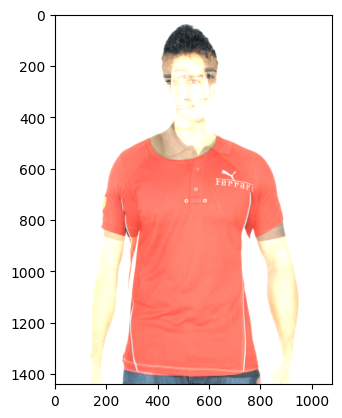

In [3]:
add_img = cv.add(img_1, img_2)
plt.imshow(add_img)

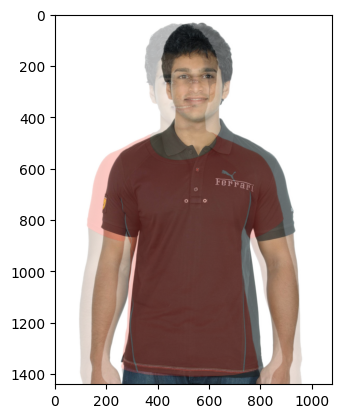

In [5]:
weighted_add = cv.addWeighted(img_1, 0.7, img_2, 0.3, 0)
plt.imshow(weighted_add)

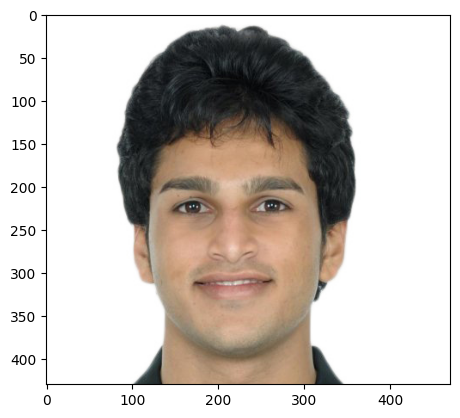

In [7]:
face = img_1[20:450, 330:800]
plt.imshow(face)

(200, 200, 3)


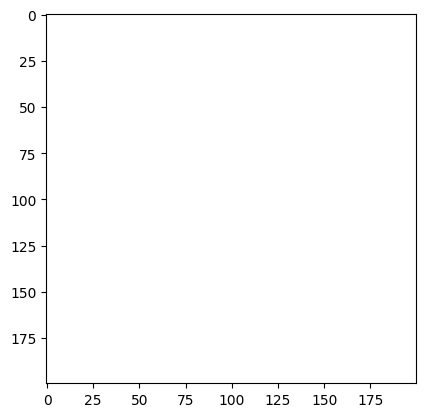

In [18]:
nike_logo = cv.imread('../Nike-Logo.png')
nike_logo = cv.cvtColor(nike_logo, cv.COLOR_BGR2RGB)
nike_logo = cv.resize(nike_logo, (200,200))
print(nike_logo.shape)
rows,cols,channels = nike_logo.shape
roi = img_1[0:rows, 0:cols]
plt.imshow(roi)

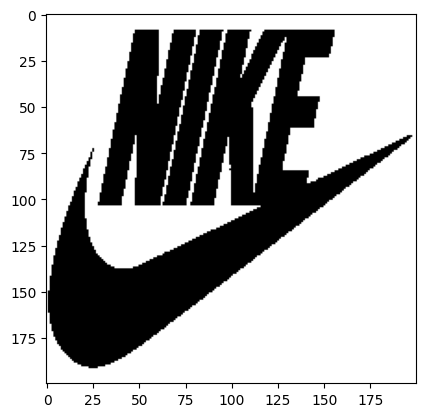

In [21]:
logo_gray = cv.cvtColor(nike_logo, cv.COLOR_RGB2GRAY)
ret, mask = cv.threshold(logo_gray, 10,255, cv.THRESH_BINARY)
plt.imshow(mask, cmap='gray')

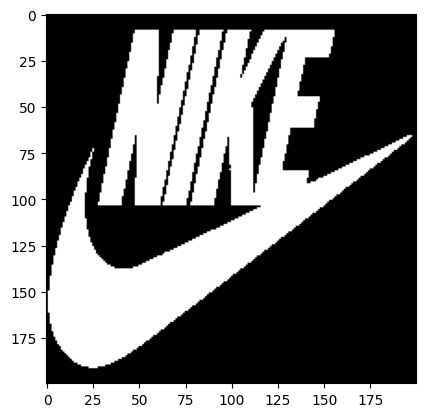

In [35]:
logo_mask_inv = cv.bitwise_not(mask)
plt.imshow(logo_mask_inv, cmap='gray')

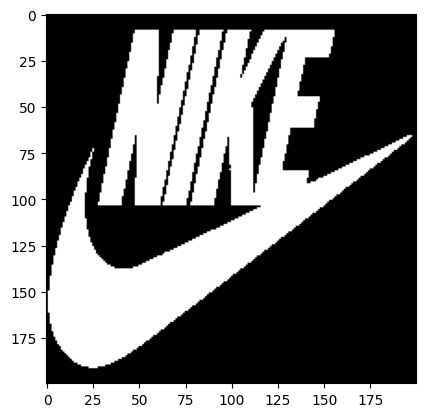

In [26]:
logo_and = cv.bitwise_and(roi, roi, mask=logo_mask_inv)
plt.imshow(logo_and)

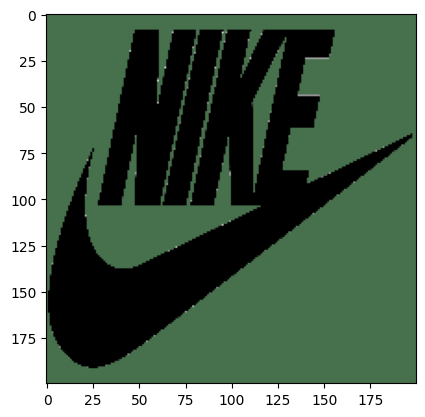

In [37]:
logo_fg = cv.bitwise_and(nike_logo, nike_logo, mask=mask)
plt.imshow(logo_fg)

(200, 200, 3)


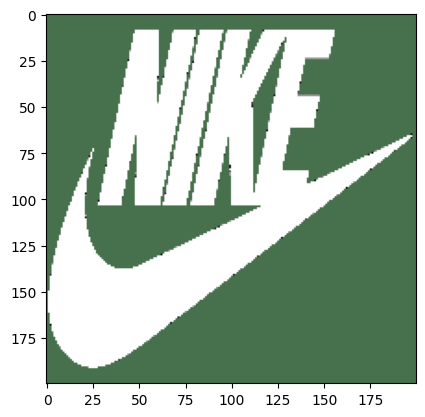

In [41]:
dst = cv.add(logo_and, logo_fg )
print(dst.shape)
plt.imshow(dst, cmap='gray')

4.58 μs ± 68.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


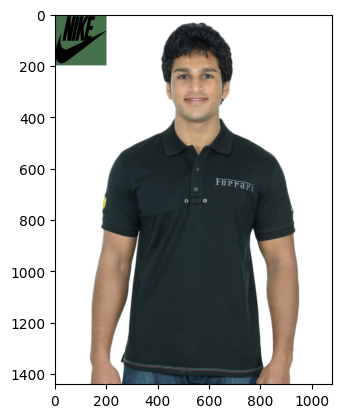

In [43]:
%timeit img_1[0:rows, 0:cols] = logo_fg
plt.imshow(img_1, cmap='gray')